# Experiment 7 — Feature-Augmented ICP vs Baseline

**Goal:** Compare three ICP variants on 10 seeds (clustered cloud, N=200):
1. **Baseline** — Gaussian matcher with sigma annealing, no features.
2. **Additive** — same matcher + `alpha * cos_sim` added to log-weights (`IdentityFeatureExtractor`).
3. **Append** — feature vectors appended to 3D coordinates before the KDTree; Gaussian weights from spatial distance only.

**Note:** `IdentityFeatureExtractor` returns `np.eye(N)` (D = N), so N=200 is used to keep memory tractable.

In [1]:
import sys
import time

from transformation import Transformation

sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from icp import ICP, SigmaAnnealingCallback, ICPResult
from matcher import GaussianMatcher
from feature_extractor import GeometricFeatureExtractor, IdentityFeatureExtractor
from synthetic import SyntheticExperiment
from algebra_utils import rotation_angle_error
from visualization import ErrorMetricsVisualizer
from tqdm import tqdm
from typing import Callable

plt.style.use('seaborn-v0_8-whitegrid')

N_SEEDS      = 5
MAX_ITER     = 200
TOL          = 1e-10
SIGMA_INIT   = 20.0
SIGMA_FINAL  = 1.0
K            = 10      # Number of points considered by the matcher
FE_K         = K       # Number of points considered by the feature extractor
ALPHA        = 5.0     # additive mode: cosine similarity weight (geometric)
BETA         = 1.0     # append mode: feature scale relative to spatial coords (geometric)
ALPHA_ID     = 5.0     # additive mode weight for IdentityFeatureExtractor
BETA_ID      = 1.0     # append mode scale for IdentityFeatureExtractor
CLOUD_STYLE  = "clustered"
N_POINTS     = 200
GEN_KWARGS   = dict(n=N_POINTS, noise_std=0.0, t_scale=8.0, style=CLOUD_STYLE)

## 1. ICP Factories

All three variants use identical sigma annealing. The two feature variants differ only in how the feature term is integrated into the E-step.

In [2]:
def make_baseline() -> ICP:
    matcher  = GaussianMatcher(sigma=SIGMA_INIT, k=K)
    annealer = SigmaAnnealingCallback(matcher, SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer])

def make_additive_icp() -> ICP:
    """GeometricFeatureExtractor, additive mode."""
    matcher  = GaussianMatcher(sigma=SIGMA_INIT, k=K,
                               feature_extractor=GeometricFeatureExtractor(k=FE_K),
                               feature_mode='additive', alpha=ALPHA)
    annealer = SigmaAnnealingCallback(matcher, SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer])

def make_append_icp() -> ICP:
    """GeometricFeatureExtractor, append mode."""
    matcher  = GaussianMatcher(sigma=SIGMA_INIT, k=K,
                               feature_extractor=GeometricFeatureExtractor(k=FE_K),
                               feature_mode='append', beta=BETA)
    annealer = SigmaAnnealingCallback(matcher, SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer])

def make_identity_additive_icp() -> ICP:
    """IdentityFeatureExtractor, additive mode — oracle correspondence signal."""
    matcher  = GaussianMatcher(sigma=SIGMA_INIT, k=K,
                               feature_extractor=IdentityFeatureExtractor(),
                               feature_mode='additive', alpha=ALPHA_ID)
    annealer = SigmaAnnealingCallback(matcher, SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer])

def make_identity_append_icp() -> ICP:
    """IdentityFeatureExtractor, append mode — oracle correspondence signal."""
    matcher  = GaussianMatcher(sigma=SIGMA_INIT, k=K,
                               feature_extractor=IdentityFeatureExtractor(),
                               feature_mode='append', beta=BETA_ID)
    annealer = SigmaAnnealingCallback(matcher, SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer])

## 2. Run ICP on several Seeds

In [3]:
def collect_results(icp_factory: Callable[[], ICP], n_seeds: int) -> tuple[list[ICPResult], list[Transformation]]:
    """Run ICP on n_seeds experiments; return ICPResult and ground-truth lists."""
    results, ground_truths = [], []
    for seed in tqdm(range(n_seeds)):
        exp = SyntheticExperiment.generate(**GEN_KWARGS, seed=seed)
        result = icp_factory().fit(exp.P, exp.Q)
        results.append(result)
        ground_truths.append(exp.T_gt)
    print(f"Finished in {sum(r.duration_s for r in results):.2f} seconds")
    return results, ground_truths


print('Running baseline ICP ...')
results_b, gts_b = collect_results(make_baseline, N_SEEDS)

print('Running geometric additive ICP ...')
results_add, gts_add = collect_results(make_additive_icp, N_SEEDS)

print('Running geometric append ICP ...')
results_app, gts_app = collect_results(make_append_icp, N_SEEDS)

print('Running identity additive ICP ...')
results_id_add, gts_id_add = collect_results(make_identity_additive_icp, N_SEEDS)

print('Running identity append ICP ...')
results_id_app, gts_id_app = collect_results(make_identity_append_icp,   N_SEEDS)

Running baseline ICP ...


100%|██████████| 5/5 [00:01<00:00,  4.68it/s]


Finished in 1.05 seconds
Running geometric additive ICP ...


100%|██████████| 5/5 [00:06<00:00,  1.24s/it]


Finished in 6.18 seconds
Running geometric append ICP ...


...

Finished in 5.22 seconds
Running identity additive ICP ...


100%|██████████| 5/5 [00:06<00:00,  1.38s/it]


Finished in 6.89 seconds
Running identity append ICP ...


100%|██████████| 5/5 [00:00<00:00, 26.78it/s]

Finished in 0.18 seconds


## 3. Convergence Curves — Mean ± Std across 10 Seeds

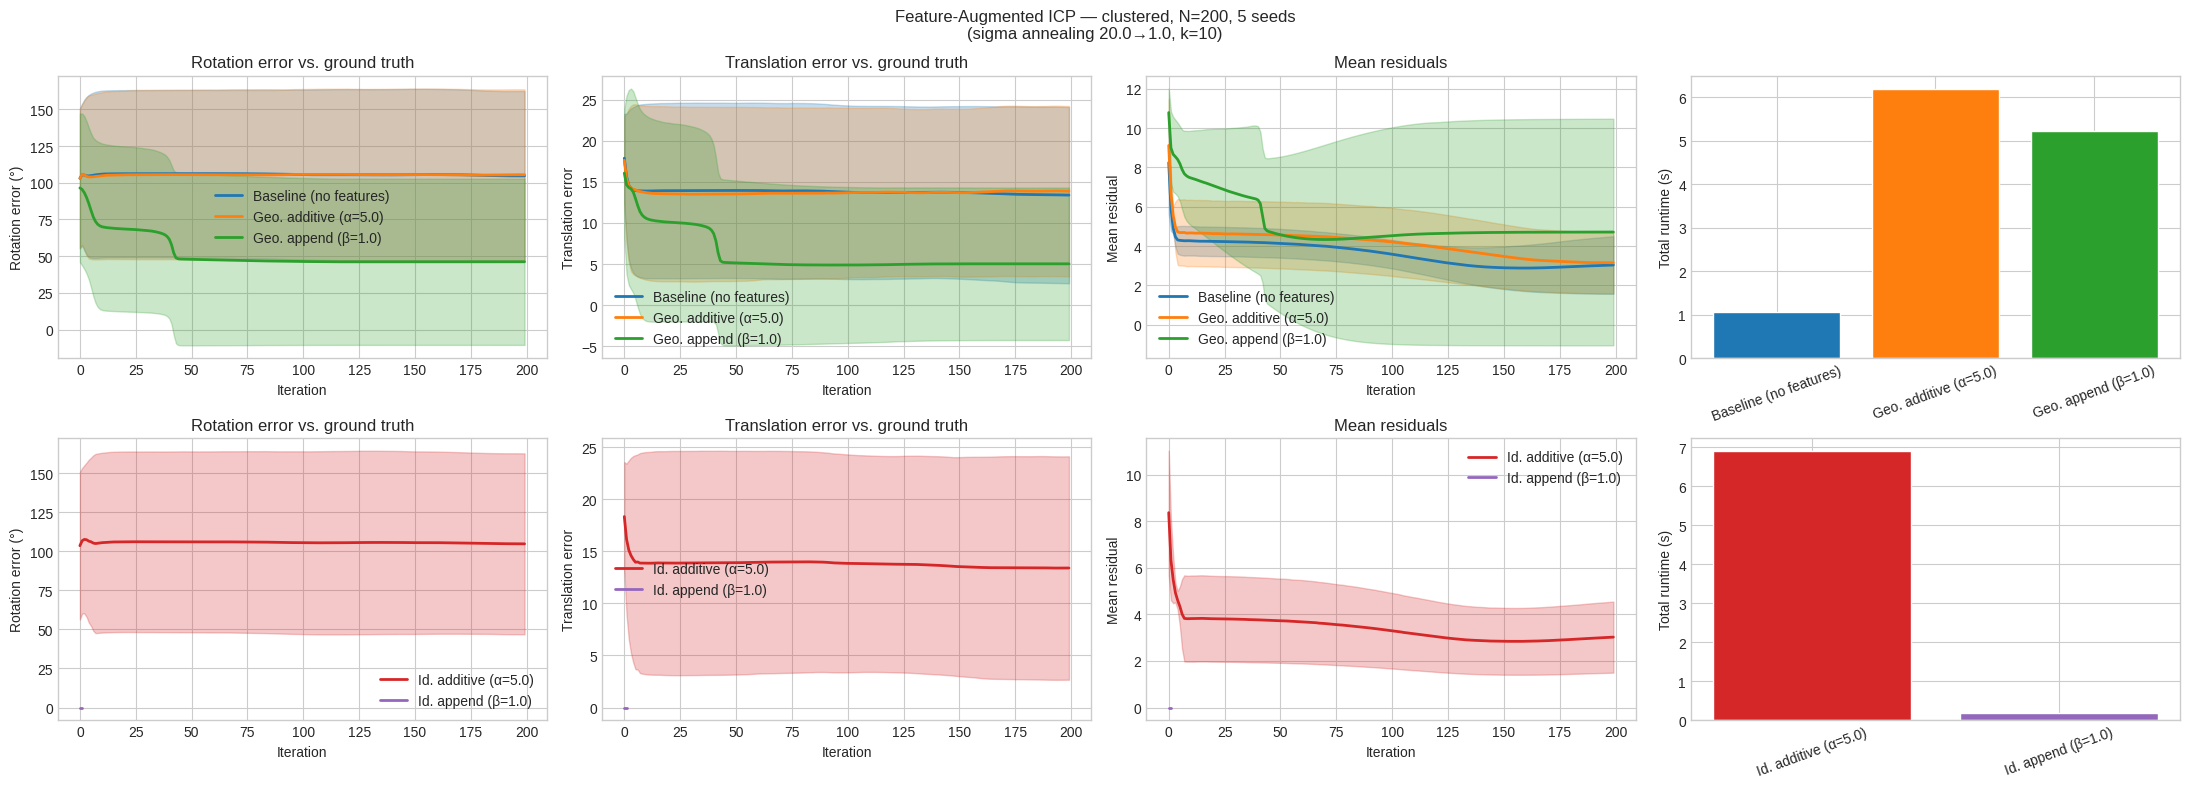

In [7]:
METHODS = [
    (results_b,       gts_b,       'Baseline (no features)',             'tab:blue'),
    (results_add,     gts_add,     f'Geo. additive (α={ALPHA})',         'tab:orange'),
    (results_app,     gts_app,     f'Geo. append (β={BETA})',            'tab:green'),
]
METHODS2 = [
    (results_id_add,  gts_id_add,  f'Id. additive (α={ALPHA_ID})',       'tab:red'),
    (results_id_app,  gts_id_app,  f'Id. append (β={BETA_ID})',          'tab:purple'),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 8))

ErrorMetricsVisualizer.plot_convergence_shaded(
    axes=axes[0, :3],
    results_per_method=[m[0] for m in METHODS],
    ground_truths_per_method=[m[1] for m in METHODS],
    method_labels=[m[2] for m in METHODS],
    colors=[m[3] for m in METHODS],
)
ErrorMetricsVisualizer.plot_convergence_shaded(
    axes=axes[1, :3],
    results_per_method=[m[0] for m in METHODS2],
    ground_truths_per_method=[m[1] for m in METHODS2],
    method_labels=[m[2] for m in METHODS2],
    colors=[m[3] for m in METHODS2],
)

axes[0, -1].bar(
    x=[m[2] for m in METHODS],
    height=[sum(r.duration_s for r in m[0]) for m in METHODS],
    color=[m[3] for m in METHODS],
)
axes[1, -1].bar(
    x=[m[2] for m in METHODS2],
    height=[sum(r.duration_s for r in m[0]) for m in METHODS2],
    color=[m[3] for m in METHODS2],
)
axes[0, -1].set_ylabel('Total runtime (s)')
axes[0, -1].tick_params(axis='x', rotation=20)
axes[1, -1].set_ylabel('Total runtime (s)')
axes[1, -1].tick_params(axis='x', rotation=20)

fig.suptitle(
    f'Feature-Augmented ICP — {CLOUD_STYLE}, N={N_POINTS}, {N_SEEDS} seeds\n'
    f'(sigma annealing {SIGMA_INIT}→{SIGMA_FINAL}, k={K})'
)
plt.tight_layout()
plt.savefig('../results/7_feature_icp_comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Impact of parameter $k$ for the Feature Extractor

In [ ]:
FE_K_VALUES = list(range(2, 21))

sweep_results = []  # one dict per fe_k value

for fe_k in tqdm(FE_K_VALUES, desc='fe_k sweep'):
    def make_sweep_icp(fe_k=fe_k) -> ICP:
        matcher  = GaussianMatcher(sigma=SIGMA_INIT, k=K,
                                   feature_extractor=GeometricFeatureExtractor(k=fe_k),
                                   feature_mode='append', alpha=ALPHA)
        annealer = SigmaAnnealingCallback(matcher, SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
        return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer])

    rot_errs, t_errs, residuals = [], [], []
    t0 = time.perf_counter()
    for seed in range(N_SEEDS):
        exp    = SyntheticExperiment.generate(**GEN_KWARGS, seed=seed)
        result = make_sweep_icp().fit(exp.P, exp.Q)
        rot_errs.append(rotation_angle_error(exp.T_gt.R, result.transformation.R))
        t_errs.append(float(np.linalg.norm(exp.T_gt.t - result.transformation.t)))
        residuals.append(float(result.mean_residuals[-1]))
    elapsed = time.perf_counter() - t0

    sweep_results.append({
        'fe_k':     fe_k,
        'rot_err':  np.array(rot_errs),
        't_err':    np.array(t_errs),
        'residual': np.array(residuals),
        'time_s':   elapsed,
    })

In [ ]:
ks            = np.array([r['fe_k']    for r in sweep_results])
rot_mean      = np.array([r['rot_err'].mean()  for r in sweep_results])
rot_std       = np.array([r['rot_err'].std()   for r in sweep_results])
t_mean        = np.array([r['t_err'].mean()    for r in sweep_results])
t_std         = np.array([r['t_err'].std()     for r in sweep_results])
res_mean      = np.array([r['residual'].mean() for r in sweep_results])
res_std       = np.array([r['residual'].std()  for r in sweep_results])
time_per_seed = np.array([r['time_s'] / N_SEEDS for r in sweep_results])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
COLOR = 'tab:purple'

metrics = [
    (axes[0], rot_mean,      rot_std, 'Rotation error (°)',   True),
    (axes[1], t_mean,        t_std,   'Translation error',    True),
    (axes[2], res_mean,      res_std, 'Mean residual',        True),
    (axes[3], time_per_seed, None,    'Runtime per seed (s)', False),
]

for ax, mean, std, ylabel, shaded in metrics:
    ax.plot(ks, mean, color=COLOR, marker='o', markersize=4)
    if shaded and std is not None:
        ax.fill_between(ks, mean - std, mean + std, alpha=0.25, color=COLOR)
    ax.set_xlabel('fe_k (feature extractor neighbors)')
    ax.set_ylabel(ylabel)
    ax.set_xticks(ks)

fig.suptitle(
    f'Additive feature ICP — effect of fe_k  '
    f'(α={ALPHA}, matcher k={K}, {N_SEEDS} seeds, {GEN_KWARGS["style"]})'
)
plt.tight_layout()
plt.savefig('../results/7_feature_icp_comparison_k_sweep.png', dpi=150, bbox_inches='tight')
plt.show()